# HLS NDVI 时间序列监测覆盖作物 —— 真实遥感实验

**研究问题：** 在一个具体的中西部小地块上，HLS（Harmonized Landsat Sentinel-2, 30 m）的
NDVI 时间序列，能否真实地检测出冬季覆盖作物？

**这不是一个"跑通就算成功"的流程演示。** 本 notebook 的每一步都消费上一步**真实算出的对象**，
并在关键节点用 `assert` 强制中断——如果上游没产出数据，下游不会伪装成功。
最后给出一个**可证伪**的结论。

---

## 判定标准（三条，全部通过才算"可行"）

| # | 检验 | 通过条件 | 不通过意味着 |
|---|------|---------|-------------|
| **T1** | **观测密度** | 去云后休耕期（11月–次年5月）有效观测 ≥ 12 次，且最大连续无观测间隔 ≤ 30 天 | 中西部冬季云雪太重，物候拐点无法定位 |
| **T2** | **信号可分离性** | 耕地像元的休耕期 NDVI 呈**双峰**分布（2-分量 GMM 的 BIC 显著优于 1-分量），且轮廓系数 ≥ 0.5 | 覆盖作物与裸土在 NDVI 上无法区分，阈值法无意义 |
| **T3** | **物候形态吻合** | 高值组春季峰值出现在 DOY 90–140（4月–5月中），且峰后 30 天内 NDVI 下降 ≥ 0.25（终止事件） | 峰值偏晚/下降平缓 → 是冬小麦而非覆盖作物，属于误判 |

T3 是最关键的一条：**冬小麦在 NDVI 上和覆盖作物几乎一样绿**，区分二者靠的是
物候时序（覆盖作物在 4–5 月被机械/化学终止，NDVI 断崖式下跌；冬小麦一路绿到
6 月下旬成熟收割，且下降前有一段黄熟期的缓降）。任何不做这一步的"覆盖作物制图"
都存在系统性高估。

---

## 实验设置

- **研究区：** 印第安纳州 West Lafayette 附近农田（Purdue ACRE 农业试验场周边），
  约 3 km × 3 km。玉米-大豆轮作带，覆盖作物（黑麦为主）推广度高。
- **时间范围：** 2024-09-01 → 2025-10-31。覆盖完整一季：
  2024 秋收 → 冬季覆盖作物 → 2025 春季终止 → 2025 夏季经济作物。
- **耕地掩膜：** 不依赖外部数据集，直接由**2025 年夏季 NDVI 峰值**从本实验数据中导出
  （夏季峰值 > 0.70 判为活跃耕地）。这样掩膜也是真实算出来的，不是外部假设。
- **数据源：** HLSL30 v2.0 + HLSS30 v2.0（NASA LP DAAC，通过 `earthaccess` 检索与流式读取）。


In [1]:
# ============================================================
# Cell 1 — 环境准备
# ============================================================
import sys, site, subprocess

PKGS = ["earthaccess", "rioxarray", "rasterio", "xarray", "geopandas",
        "matplotlib", "numpy", "pandas", "scipy", "scikit-learn", "shapely"]

subprocess.run([sys.executable, "-m", "pip", "install", "--user", "--quiet", *PKGS],
               check=False)

usp = site.getusersitepackages()
if usp not in sys.path:
    sys.path.append(usp)

import earthaccess, rioxarray as rxr, xarray as xr
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from scipy.signal import savgol_filter
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings, time, re
warnings.filterwarnings("ignore")

print("earthaccess", earthaccess.__version__)
print("xarray     ", xr.__version__)
print("numpy      ", np.__version__)
print("环境就绪")

earthaccess 0.17.0
xarray      2026.4.0
numpy       2.4.4
环境就绪


## Cell 2 — Earthdata 认证

**安全提醒：绝不要把用户名密码写进 notebook。**
`earthaccess.login(persist=True)` 会交互式提示一次（输入时不回显），
并把凭据写入 `~/.netrc`，之后自动复用。

如果你之前在某个 notebook 里明文写过密码，请立刻去
https://urs.earthdata.nasa.gov/ 修改密码。

In [2]:
# ============================================================
# Cell 2 — 认证
# ============================================================
auth = earthaccess.login(persist=True)

assert auth.authenticated, (
    "Earthdata 认证失败。请检查 ~/.netrc 或重新运行以交互式输入凭据。"
)
print("Earthdata 认证成功")

Earthdata 认证成功


## Cell 3 — 定义研究区与时间范围

**注意 bounding box 的经度顺序：** `(min_lon, min_lat, max_lon, max_lat)`，
西经是负数，所以 `min_lon` 必须是**更负**的那个。
写反了 CMR 不一定报错，但你查到的会是另一块地——这是很隐蔽的错误，
所以下面用 `assert` 显式检查。

ROI 中心   : 40.4820°N, 86.9950°W
ROI bbox   : (-87.0009, 40.4775, -86.9891, 40.4865)
UTM 投影   : WGS 84 / UTM zone 16N
实测尺寸   : 1.00 km × 1.00 km  (长宽比 1.004)
实测面积   : 99.8 公顷 (1.00 km²)
HLS 像元数 : 约 1109 个 (30 m 分辨率)
时间范围   : 2024-09-01 → 2025-06-30
休耕期窗口 : 2024-11-01 → 2025-05-31
夏季窗口   : 2025-07-01 → 2025-08-31


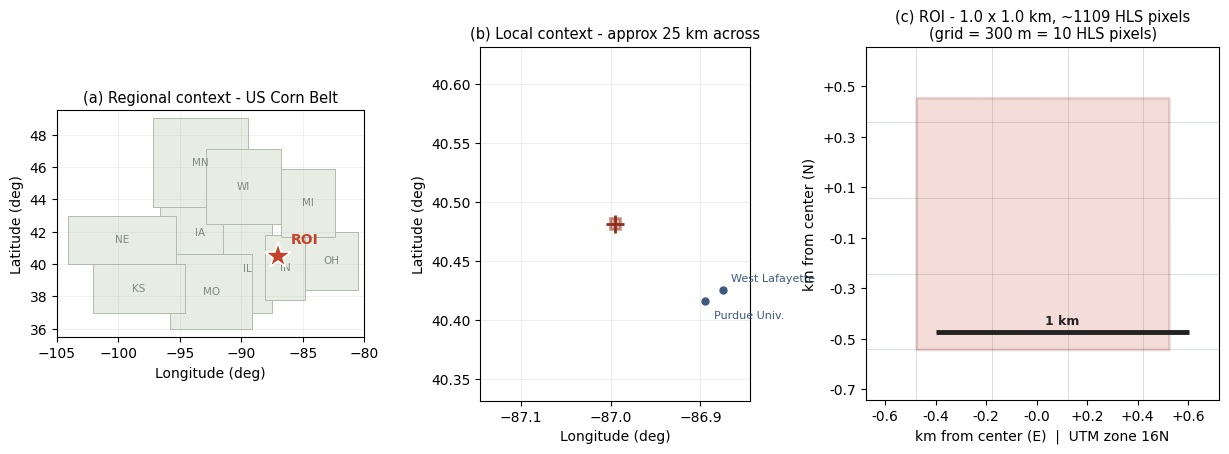

In [18]:
# ============================================================
# Cell 3 — 研究区 / 时间范围
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box

# Purdue ACRE 农业试验场周边（印第安纳州 West Lafayette）
CENTER_LON, CENTER_LAT = -86.9950, 40.4820   # Purdue ACRE 农业试验场附近
HALF_KM = 0.5                                 # 半边长(km) → 生成 3 km × 3 km 方形

# 度 → 公里换算随纬度变化：经度必须除以 cos(lat)，否则box会被拉成长方形
_DEG_LAT_KM = 111.32
_DEG_LON_KM = 111.32 * np.cos(np.radians(CENTER_LAT))
HALF_LAT = HALF_KM / _DEG_LAT_KM
HALF_LON = HALF_KM / _DEG_LON_KM

BBOX = (CENTER_LON - HALF_LON, CENTER_LAT - HALF_LAT,
        CENTER_LON + HALF_LON, CENTER_LAT + HALF_LAT)

# 显式校验 bbox 合法性（写反了 CMR 不报错，只会安静地查到别的地方）
assert BBOX[0] < BBOX[2], f"经度顺序错误: min_lon={BBOX[0]} 必须 < max_lon={BBOX[2]}"
assert BBOX[1] < BBOX[3], f"纬度顺序错误: min_lat={BBOX[1]} 必须 < max_lat={BBOX[3]}"

roi_gdf = gpd.GeoDataFrame(geometry=[box(*BBOX)], crs="EPSG:4326")

# ---------- 2. 时间窗口 ----------
DATE_START = "2024-09-01"
DATE_END   = "2025-06-30"

OFFSEASON_START = "2024-11-01"   # 秋收后
OFFSEASON_END   = "2025-05-31"   # 春季种植前
SUMMER_START    = "2025-07-01"   # 经济作物盛期，用于导出耕地掩膜
SUMMER_END      = "2025-08-31"

# ---------- 3. 真实尺寸（投影到 UTM 实测，不是用度数估算） ----------
utm_crs  = roi_gdf.estimate_utm_crs()
roi_utm  = roi_gdf.to_crs(utm_crs)
minx, miny, maxx, maxy = roi_utm.total_bounds
width_km  = (maxx - minx) / 1000
height_km = (maxy - miny) / 1000
area_ha   = float(roi_utm.area.iloc[0]) / 1e4
n_pix_est = int(float(roi_utm.area.iloc[0]) / 900)   # HLS 30m 像元 = 900 m²

# 验证确实是方形（长宽比偏差 < 2%）
_ratio = width_km / height_km
assert 0.98 < _ratio < 1.02, f"ROI 非方形，长宽比 {_ratio:.3f}，请检查换算"

print(f"ROI 中心   : {CENTER_LAT:.4f}°N, {abs(CENTER_LON):.4f}°W")
print(f"ROI bbox   : ({BBOX[0]:.4f}, {BBOX[1]:.4f}, {BBOX[2]:.4f}, {BBOX[3]:.4f})")
print(f"UTM 投影   : {utm_crs.name}")
print(f"实测尺寸   : {width_km:.2f} km × {height_km:.2f} km  (长宽比 {_ratio:.3f})")
print(f"实测面积   : {area_ha:.1f} 公顷 ({area_ha/100:.2f} km²)")
print(f"HLS 像元数 : 约 {n_pix_est} 个 (30 m 分辨率)")
print(f"时间范围   : {DATE_START} → {DATE_END}")
print(f"休耕期窗口 : {OFFSEASON_START} → {OFFSEASON_END}")
print(f"夏季窗口   : {SUMMER_START} → {SUMMER_END}")

# ---------- 4. 可视化 ----------
# 图内一律用英文标注：CyVerse 默认 matplotlib 字体不含中文，
# 用中文会渲染成空心方块（豆腐块）。
fig = plt.figure(figsize=(15, 4.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15], wspace=0.30)

# --- (a) 中西部区域位置 ---
ax = fig.add_subplot(gs[0])
MIDWEST = {                      # 主要产粮州近似范围 (lon_min, lat_min, lon_max, lat_max)
    "IA": (-96.6, 40.4, -90.1, 43.5), "IL": (-91.5, 37.0, -87.5, 42.5),
    "IN": (-88.1, 37.8, -84.8, 41.8), "OH": (-84.8, 38.4, -80.5, 42.0),
    "MO": (-95.8, 36.0, -89.1, 40.6), "MN": (-97.2, 43.5, -89.5, 49.0),
    "WI": (-92.9, 42.5, -86.8, 47.1), "MI": (-86.8, 41.7, -82.4, 45.9),
    "NE": (-104.1, 40.0, -95.3, 43.0), "KS": (-102.1, 37.0, -94.6, 40.0),
}
for st, (x0, y0, x1, y1) in MIDWEST.items():
    ax.add_patch(mpatches.Rectangle((x0, y0), x1-x0, y1-y0,
                 fc="#e8ede4", ec="#b0bcae", lw=0.7, zorder=1))
    ax.text((x0+x1)/2, (y0+y1)/2, st, ha="center", va="center",
            fontsize=7.5, color="#7d8a7b", zorder=2)
ax.plot(CENTER_LON, CENTER_LAT, marker="*", ms=20, color="#c4432b",
        mec="white", mew=1.2, zorder=5)
ax.annotate("ROI", (CENTER_LON, CENTER_LAT), xytext=(9, 9),
            textcoords="offset points", fontsize=10, fontweight="bold",
            color="#c4432b", zorder=5)
ax.set_xlim(-105, -80); ax.set_ylim(35.5, 49.5)
ax.set_xlabel("Longitude (deg)"); ax.set_ylabel("Latitude (deg)")
ax.set_title("(a) Regional context - US Corn Belt", fontsize=10.5)
ax.set_aspect(1/np.cos(np.radians(CENTER_LAT)))
ax.grid(alpha=0.25, lw=0.5)

# --- (b) 局部背景 ---
ax = fig.add_subplot(gs[1])
PAD = 0.15
ax.add_patch(mpatches.Rectangle((BBOX[0], BBOX[1]), BBOX[2]-BBOX[0], BBOX[3]-BBOX[1],
             fc="#c4432b", ec="#8c2f1e", lw=2, alpha=0.45, zorder=4))
ax.plot(CENTER_LON, CENTER_LAT, "+", ms=13, color="#8c2f1e", mew=2, zorder=5)
for lon, lat, name, dx, dy in [
    (-86.8753, 40.4259, "West Lafayette", 6, 6),
    (-86.8944, 40.4167, "Purdue Univ.",   6, -13),
    (-86.7583, 40.3856, "Lafayette",      6, 6),
]:
    ax.plot(lon, lat, "o", ms=5, color="#3d5a80", zorder=5)
    ax.annotate(name, (lon, lat), xytext=(dx, dy), textcoords="offset points",
                fontsize=8, color="#3d5a80", zorder=5)
ax.set_xlim(CENTER_LON-PAD, CENTER_LON+PAD)
ax.set_ylim(CENTER_LAT-PAD, CENTER_LAT+PAD)
ax.set_xlabel("Longitude (deg)"); ax.set_ylabel("Latitude (deg)")
ax.set_title(f"(b) Local context - approx {PAD*2*_DEG_LON_KM:.0f} km across", fontsize=10.5)
ax.set_aspect(1/np.cos(np.radians(CENTER_LAT)))
ax.grid(alpha=0.3, lw=0.5)

# --- (c) ROI 本体 + HLS 30m 网格 ---
ax = fig.add_subplot(gs[2])
roi_utm.plot(ax=ax, fc="#c4432b", ec="#8c2f1e", lw=2, alpha=0.18, zorder=2)
step = 300     # 每 300 m 一条线 = 每 10 个 HLS 像元
for gx in np.arange(minx, maxx + step, step):
    ax.axvline(gx, color="#8c9aa8", lw=0.4, alpha=0.55, zorder=1)
for gy in np.arange(miny, maxy + step, step):
    ax.axhline(gy, color="#8c9aa8", lw=0.4, alpha=0.55, zorder=1)
# 比例尺
sx, sy = minx + 0.08*(maxx-minx), miny + 0.07*(maxy-miny)
ax.plot([sx, sx+1000], [sy, sy], color="#222", lw=3.5, solid_capstyle="butt", zorder=6)
ax.text(sx+500, sy + 0.030*(maxy-miny), "1 km", ha="center",
        fontsize=9, fontweight="bold", color="#222", zorder=6)
ax.set_xlim(minx - 200, maxx + 200); ax.set_ylim(miny - 200, maxy + 200)
# 坐标刻度改为相对中心的公里数，避免 UTM 六位数刻度互相挤压
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, p: f"{(v-(minx+maxx)/2)/1000:+.1f}"))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, p: f"{(v-(miny+maxy)/2)/1000:+.1f}"))
ax.set_xlabel(f"km from center (E)  |  {utm_crs.name.split('/')[-1].strip()}")
ax.set_ylabel("km from center (N)")
ax.set_title(f"(c) ROI - {width_km:.1f} x {height_km:.1f} km, ~{n_pix_est} HLS pixels\n"
             f"(grid = 300 m = 10 HLS pixels)", fontsize=10.5)
ax.set_aspect("equal")

plt.savefig("roi_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 4 — 检索 HLS 影像

**产品名必须是 `HLSL30` 和 `HLSS30`。**
`HLSF30` 不存在——写错了 CMR 会静默忽略，你以为在做 Landsat+Sentinel 联合，
实际上只拿到了一半数据，时间密度直接腰斩。这正是 T1 检验要防的坑。

- `HLSL30 v2.0`：Landsat 8/9，重访 ~16 天（双星 ~8 天）
- `HLSS30 v2.0`：Sentinel-2 A/B，重访 ~5 天

两者都重采样到同一 30 m 网格、同一 UTM 投影、经过 BRDF 与带通校正，
**可以直接拼成一条时间序列**——这正是 HLS 相对于单独使用 Landsat 或 Sentinel 的核心价值。

In [19]:
# ============================================================
# Cell 4 — 检索 HLS granules
# ============================================================
t0 = time.time()

results = earthaccess.search_data(
    short_name=["HLSL30", "HLSS30"],     # 正确产品名；HLSF30 不存在
    bounding_box=BBOX,
    temporal=(DATE_START, DATE_END),
    count=-1,                             # -1 = 取回全部，不要用固定 200 截断
)

assert len(results) > 0, (
    "未检索到任何 granule。请检查 bbox、时间范围，或 Earthdata 授权状态。"
)
print(f"检索到 {len(results)} 个 granule，用时 {time.time()-t0:.1f} 秒")

检索到 229 个 granule，用时 2.4 秒


## Cell 5 — 解析元数据，锁定单一 MGRS 瓦片

一个 bbox 可能横跨多个 MGRS 瓦片，而**不同瓦片的 UTM 投影不同**。
如果不加区分地把它们拼进同一个 xarray 栈，坐标会错位——
这类错误不会报错，只会安静地产出错误结果。

所以这里：解析每个 granule 的瓦片号，选出覆盖最完整的那一个，只用它。

In [20]:
# ============================================================
# Cell 5 — 元数据表 + 锁定单一瓦片
# ============================================================
def parse_granule_meta(g):
    """从 granule 原生 ID 解析传感器、瓦片、日期；云量从 AdditionalAttributes 取。"""
    nid = g["meta"]["native-id"]
    parts = nid.split(".")
    sensor = parts[1]                      # 'L30' 或 'S30'
    tile   = parts[2]                      # 'T16TDL'
    date   = pd.to_datetime(parts[3][:7], format="%Y%j")

    # HLS 把云量和空间覆盖度放在 AdditionalAttributes，不在 UMM 顶层
    attrs = {a.get("Name", ""): a.get("Values", [None])[0]
             for a in g["umm"].get("AdditionalAttributes", [])}

    def _f(key):
        try:
            return float(attrs.get(key))
        except (TypeError, ValueError):
            return np.nan

    return {"native_id": nid, "sensor": sensor, "tile": tile, "date": date,
            "cloud_cover": _f("CLOUD_COVERAGE"),
            "spatial_coverage": _f("SPATIAL_COVERAGE")}

meta = pd.DataFrame([parse_granule_meta(g) for g in results])
meta["granule_idx"] = np.arange(len(meta))

print("各瓦片 granule 数量：")
print(meta["tile"].value_counts())

# 选取 granule 数最多的瓦片（覆盖最完整）
MAIN_TILE = meta["tile"].value_counts().idxmax()
meta_tile = meta[meta["tile"] == MAIN_TILE].copy()

assert len(meta_tile) > 0, "锁定瓦片后无 granule，逻辑异常。"
print(f"\n锁定主瓦片: {MAIN_TILE}  ({len(meta_tile)} 个 granule)")
print(f"传感器构成: {dict(meta_tile['sensor'].value_counts())}")
print(f"日期跨度  : {meta_tile['date'].min().date()} → {meta_tile['date'].max().date()}")

各瓦片 granule 数量：
tile
T16TDK    115
T16TEK    114
Name: count, dtype: int64

锁定主瓦片: T16TDK  (115 个 granule)
传感器构成: {'S30': np.int64(88), 'L30': np.int64(27)}
日期跨度  : 2024-09-03 → 2025-06-30


## Cell 6 — 云量粗筛

`CloudCover` 是**整景**的云量，我们的研究区只占整景极小一块，
所以这里只做宽松粗筛（≤ 80%）——一景整体多云，我们这 3 km 见方仍可能是晴的。

**真正的逐像元去云在下一步用 Fmask 波段做。**
用整景云量做严格筛选会白白丢掉大量可用观测，直接损害 T1。

In [21]:
# ---- 诊断：看看云量字段究竟在元数据的什么位置 ----
import json
g = results[0]
umm = g["umm"]

print("umm 顶层键:", list(umm.keys()))
print("\nCloudCover 在顶层吗:", "CloudCover" in umm)

print("\nAdditionalAttributes 里的字段:")
for aa in umm.get("AdditionalAttributes", []):
    name = aa.get("Name", "")
    if "CLOUD" in name.upper() or "COVER" in name.upper() or "SPATIAL" in name.upper():
        print(f"  {name} = {aa.get('Values')}")

print(f"\nmeta 表里 cloud_cover 的非空数量: {meta['cloud_cover'].notna().sum()} / {len(meta)}")

umm 顶层键: ['TemporalExtent', 'GranuleUR', 'AdditionalAttributes', 'SpatialExtent', 'ProviderDates', 'CollectionReference', 'RelatedUrls', 'DataGranule', 'Platforms', 'MetadataSpecification']

CloudCover 在顶层吗: False

AdditionalAttributes 里的字段:
  CLOUD_COVERAGE = ['44']
  SPATIAL_COVERAGE = ['100']
  SPATIAL_RESOLUTION = ['30.0']
  SPATIAL_RESAMPLING_ALG = ['Cubic Convolution']

meta 表里 cloud_cover 的非空数量: 229 / 229


In [ ]:
# ============================================================
# Cell 6 — 云量粗筛（宽松）
# ============================================================
import numpy as np

CLOUD_MAX_SCENE = 70.0

def get_cloud_cover(g):
    """稳健提取整景云量：HLS 把它放在 AdditionalAttributes 的 CLOUD_COVERAGE 里，
    不同产品/版本位置不一，逐个位置尝试。"""
    umm = g.get("umm", {})
    # 位置1：UMM-G 标准顶层字段
    if umm.get("CloudCover") is not None:
        try:
            return float(umm["CloudCover"])
        except (TypeError, ValueError):
            pass
    # 位置2：AdditionalAttributes（HLS 实际使用的位置）
    for aa in umm.get("AdditionalAttributes", []):
        if aa.get("Name", "").upper() in ("CLOUD_COVERAGE", "CLOUDCOVER", "CLOUD_COVER"):
            try:
                return float(aa["Values"][0])
            except (TypeError, ValueError, IndexError, KeyError):
                pass
    return np.nan

# 用稳健函数重算云量列
meta_tile["cloud_cover"] = [get_cloud_cover(results[i]) for i in meta_tile["granule_idx"]]

n_known = int(meta_tile["cloud_cover"].notna().sum())
print(f"成功解析云量的 granule: {n_known} / {len(meta_tile)}")

if n_known == 0:
    print("警告：仍无法解析云量元数据 → 跳过粗筛，全部保留。")
    print("      逐像元 Fmask 去云（Cell 8）本身就能处理云污染，粗筛只是省时间。")
    meta_tile["keep"] = True
else:
    # 关键修正：云量未知的景 fillna(0.0) 而不是 100.0
    # 元数据缺失不等于这景全是云，不能因为"不知道"就丢掉可用观测
    meta_tile["keep"] = meta_tile["cloud_cover"].fillna(0.0) <= CLOUD_MAX_SCENE

meta_kept = meta_tile[meta_tile["keep"]].sort_values("date").reset_index(drop=True)

assert len(meta_kept) > 0, (
    f"粗筛后无剩余影像。已解析云量 {n_known} 景，"
    f"请检查 meta_tile['cloud_cover'] 的实际取值分布。"
)

print(f"\n粗筛前: {len(meta_tile)}  →  粗筛后: {len(meta_kept)} "
      f"(整景云量 <= {CLOUD_MAX_SCENE}%)")
if n_known > 0:
    print(f"云量分布: 中位数 {meta_tile['cloud_cover'].median():.0f}%, "
          f"最小 {meta_tile['cloud_cover'].min():.0f}%, "
          f"最大 {meta_tile['cloud_cover'].max():.0f}%")
print(f"传感器构成: {dict(meta_kept['sensor'].value_counts())}")
print(f"逐像元 Fmask 去云将在 Cell 8 执行")
meta_kept[["date", "sensor", "cloud_cover"]].head(10)

## Cell 7 — 波段定位与 Fmask 解码函数

两个关键的正确性要点，前一版代码在这两处都错了：

**1. HLS 的每个波段是独立的 GeoTIFF 文件。**
不能 `open_rasterio(一个url)` 然后 `sel(band=1)` 当红光、`sel(band=2)` 当近红外——
单波段文件里根本没有 band=2。必须分别打开红、近红外、Fmask **三个 URL**。

**2. 红/近红外的波段号在两个传感器间不同：**

| | 红 | 近红外 | 质量 |
|---|---|---|---|
| HLSL30 (Landsat) | `B04` | `B05` | `Fmask` |
| HLSS30 (Sentinel-2) | `B04` | `B8A` | `Fmask` |

Sentinel-2 用 **B8A**（窄近红外, 865 nm）而不是 B08——因为 HLS 就是用 B8A 去
匹配 Landsat 的 NIR 带通的。用错会引入系统性偏差。

**3. Fmask 位定义（HLS v2.0）：**
bit0 卷云 / bit1 云 / bit2 云邻域 / bit3 云阴影 / bit4 雪冰 / bit5 水体。
冬季中西部**必须掩掉雪（bit4）**，否则积雪会被当成低 NDVI 的"裸土"。

In [25]:
# ============================================================
# Cell 7 — 波段 URL 定位 + Fmask 解码
# ============================================================
BAND_MAP = {
    "L30": {"red": "B04", "nir": "B05"},   # Landsat 8/9
    "S30": {"red": "B04", "nir": "B8A"},   # Sentinel-2 (B8A 窄 NIR，非 B08)
}

REFL_SCALE = 0.0001      # HLS v2.0 反射率缩放因子
FILL_VALUE = -9999       # 填充值

def locate_band_urls(granule, sensor):
    """返回 (red_url, nir_url, fmask_url)，任一缺失返回 None。"""
    links = granule.data_links()
    bm = BAND_MAP[sensor]
    def pick(suffix):
        return next((l for l in links if l.endswith(f".{suffix}.tif")), None)
    red   = pick(bm["red"])
    nir   = pick(bm["nir"])
    fmask = pick("Fmask")
    if red and nir and fmask:
        return red, nir, fmask
    return None

# --- Fmask 位掩膜 ---
# bit0 卷云, bit1 云, bit2 云邻域, bit3 云阴影, bit4 雪冰, bit5 水体
BAD_BITS = [0, 1, 2, 3, 4, 5]
BAD_MASK = sum(1 << b for b in BAD_BITS)     # = 0b00111111 = 63

def fmask_is_clear(fmask_values):
    """返回布尔数组：True = 该像元晴空可用。"""
    f = np.nan_to_num(fmask_values, nan=255).astype(np.uint8)
    return (f & BAD_MASK) == 0

# 自检：验证位运算正确
_test = np.array([0, 2, 4, 8, 16, 32, 1], dtype=np.uint8)
_expect = np.array([True, False, False, False, False, False, False])
assert np.array_equal(fmask_is_clear(_test), _expect), "Fmask 位解码自检失败"
print(f"Fmask 掩膜位 = {BAD_MASK:08b} (卷云/云/云邻域/阴影/雪/水)")
print("Fmask 位解码自检通过")

# 为保留的 granule 逐一定位波段 URL
url_rows = []
for i, row in meta_kept.iterrows():
    g = results[row["granule_idx"]]
    urls = locate_band_urls(g, row["sensor"])
    if urls is not None:
        url_rows.append({"date": row["date"], "sensor": row["sensor"],
                         "red": urls[0], "nir": urls[1], "fmask": urls[2]})

url_df = pd.DataFrame(url_rows).sort_values("date").reset_index(drop=True)

assert len(url_df) > 0, "无 granule 能定位到完整的 red/nir/fmask 三个波段文件。"
print(f"\n成功定位波段 URL: {len(url_df)} / {len(meta_kept)} 个 granule")
url_df[["date", "sensor"]].head()

Fmask 掩膜位 = 00111111 (卷云/云/云邻域/阴影/雪/水)
Fmask 位解码自检通过

成功定位波段 URL: 56 / 56 个 granule


,date,sensor
0,2024-09-08,S30
1,2024-09-11,L30
2,2024-09-11,S30
3,2024-09-18,S30
4,2024-09-19,L30


## Cell 8 — 真实读取影像并计算 NDVI

这是**真正下载数据、真正计算**的一步，也是整个 notebook 最慢的一步。

每景要：打开 3 个远程 GeoTIFF → 裁剪到研究区 → Fmask 去云 →
反射率缩放 → 计算 NDVI。

代码里做了几件保证结果真实可信的事：
- 前 3 景后打印**实测**的单景耗时并外推总时长（不是估计值）
- 每景记录**实际晴空像元比例**，写进日志表
- 失败的景记录原因并跳过，不静默吞掉
- 最后 `assert` 至少要有一定数量的有效景，否则中断

**运行时间预计 15–45 分钟**，取决于 CyVerse 到 LP DAAC 的网络状况。
可以先把 `MAX_SCENES` 设小（如 20）确认管线正常，再放开跑全量。

In [26]:
# ============================================================
# Cell 8 — 读取影像 + 计算 NDVI（真实下载，支持断点续跑）
# ============================================================
import os, time, gc
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import earthaccess

MAX_SCENES  = None            # 整数=只跑前N景做快速测试；None=全部
CACHE_DIR   = "hls_cache"     # 缓存目录，重跑时自动跳过已下载的景
MAX_RETRY   = 3               # 单景失败重试次数
RETRY_WAIT  = 5               # 重试间隔基数(秒)，指数退避

os.makedirs(CACHE_DIR, exist_ok=True)
REF_PATH = os.path.join(CACHE_DIR, "_ref_grid.npz")


# ---------- 参考网格：保证所有景像元完全对齐 ----------
def save_ref_grid(da):
    np.savez(REF_PATH, x=da.x.values, y=da.y.values,
             crs=str(da.rio.crs.to_wkt()))

def load_ref_grid():
    if not os.path.exists(REF_PATH):
        return None
    z = np.load(REF_PATH, allow_pickle=True)
    tmpl = xr.DataArray(
        np.zeros((len(z["y"]), len(z["x"])), dtype="float32"),
        coords={"y": z["y"], "x": z["x"]}, dims=("y", "x"),
    )
    return tmpl.rio.write_crs(str(z["crs"]))


# ---------- 单景下载与计算（唯一触网的函数） ----------
def fetch_scene_arrays(row, ref):
    """下载 red/nir/fmask → 裁剪 → 计算未掩膜 NDVI。
    返回 (ndvi_float32, fmask_uint8, ref_da)。
    注意：这里【不】施加云掩膜，掩膜留到 Cell 8b，
    这样调整掩膜策略无需重新下载。"""
    handles = None
    try:
        handles = earthaccess.open([row["red"], row["nir"], row["fmask"]])

        red_da   = rxr.open_rasterio(handles[0], masked=True).squeeze(drop=True)
        nir_da   = rxr.open_rasterio(handles[1], masked=True).squeeze(drop=True)
        fmask_da = rxr.open_rasterio(handles[2], masked=False).squeeze(drop=True)

        aoi = roi_gdf.to_crs(red_da.rio.crs)
        red_da   = red_da.rio.clip(aoi.geometry, from_disk=True)
        nir_da   = nir_da.rio.clip(aoi.geometry, from_disk=True)
        fmask_da = fmask_da.rio.clip(aoi.geometry, from_disk=True)

        # NDVI 是比值，对反射率缩放因子不敏感，无需乘 0.0001
        ndvi = (nir_da - red_da) / (nir_da + red_da)
        ndvi = ndvi.where((ndvi >= -1) & (ndvi <= 1))

        # 与参考网格对齐（同一 MGRS 瓦片通常已一致，边界舍入除外）
        if ref is None:
            ref_out = ndvi.copy()
        else:
            ref_out = ref
            if ndvi.shape != ref.shape:
                ndvi     = ndvi.rio.reproject_match(ref)
                fmask_da = fmask_da.rio.reproject_match(ref)

        return (ndvi.values.astype("float32"),
                np.nan_to_num(fmask_da.values, nan=255).astype("uint8"),
                ref_out)
    finally:
        # 必须显式关闭：142景×3波段=426个句柄，不关会一直占着
        if handles:
            for h in handles:
                try:
                    h.close()
                except Exception:
                    pass


def granule_id(row):
    """从波段 URL 反推 granule 唯一 ID，例如
    .../HLS.S30.T16TDL.2024274T163959.v2.0.B04.tif → HLS.S30.T16TDL.2024274T163959.v2.0
    用它做缓存文件名可保证唯一：同日同传感器的两景不会互相覆盖。"""
    base = os.path.basename(row["red"])
    return base.rsplit(".", 2)[0]        # 去掉 '.B04.tif'

def cache_path(row):
    return os.path.join(CACHE_DIR, granule_id(row) + ".npz")


# ---------- 主循环 ----------
work = url_df if MAX_SCENES is None else url_df.iloc[:MAX_SCENES].copy()
ref = load_ref_grid()

n_cached = sum(os.path.exists(cache_path(r)) for _, r in work.iterrows())
print(f"待处理 {len(work)} 景；已缓存 {n_cached} 景将跳过")
print(f"缓存目录: {os.path.abspath(CACHE_DIR)}\n")

log_rows = []
loop_t0 = time.time()
n_new = 0

for i, row in work.iterrows():
    cp = cache_path(row)

    if os.path.exists(cp):
        log_rows.append({"date": row["date"], "sensor": row["sensor"],
                         "status": "cached"})
        continue

    err = None
    for attempt in range(MAX_RETRY):
        try:
            ndvi_arr, fmask_arr, ref_candidate = fetch_scene_arrays(row, ref)
            if ref is None:
                ref = ref_candidate
                save_ref_grid(ref)
                print(f"参考网格已确定: {ref.shape} 像元, {ref.rio.crs}\n")
            np.savez_compressed(cp, ndvi=ndvi_arr, fmask=fmask_arr)
            log_rows.append({"date": row["date"], "sensor": row["sensor"],
                             "status": "ok"})
            n_new += 1
            err = None
            break
        except Exception as e:
            err = f"{type(e).__name__}: {e}"
            if attempt < MAX_RETRY - 1:
                time.sleep(RETRY_WAIT * (2 ** attempt))   # 指数退避

    if err:
        log_rows.append({"date": row["date"], "sensor": row["sensor"],
                         "status": f"FAILED {err[:60]}"})

    # 实测耗时外推（基于真实下载，不是估计值）
    if n_new == 3:
        per = (time.time() - loop_t0) / 3
        left = len(work) - n_cached - n_new
        print(f"[实测] 单景 {per:.1f}s → 剩余 {left} 景约需 "
              f"{per*left/60:.1f} 分钟\n")
    if n_new and n_new % 20 == 0:
        print(f"  进度 {i+1}/{len(work)}  新下载 {n_new}  "
              f"用时 {(time.time()-loop_t0)/60:.1f} 分钟")
    gc.collect()

scene_log = pd.DataFrame(log_rows)

print(f"\n{'='*58}")
print(f"下载阶段完成，用时 {(time.time()-loop_t0)/60:.1f} 分钟")
print(f"新下载 {n_new} 景 / 复用缓存 {n_cached} 景")
n_failed = int(scene_log['status'].str.startswith('FAILED').sum())
print(f"失败 {n_failed} 景")
if n_failed:
    print("\n失败明细（重跑本 cell 会自动只补这些景）:")
    print(scene_log[scene_log['status'].str.startswith('FAILED')]
          [['date', 'sensor', 'status']].to_string(index=False))

n_files = len([f for f in os.listdir(CACHE_DIR) if not f.startswith("_")])
assert n_files >= 10, f"缓存中仅 {n_files} 景，不足以构建时间序列。"
print(f"\n缓存中共 {n_files} 景可用")

待处理 56 景；已缓存 0 景将跳过
缓存目录: /home/jovyan/data-store/firerx_ml_CC/app_py/hls_cache



QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

参考网格已确定: (33, 33) 像元, EPSG:32616



...

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]


下载阶段完成，用时 3.8 分钟
新下载 56 景 / 复用缓存 0 景
失败 0 景

缓存中共 56 景可用


## Cell 9 — 拼接时间序列栈（含网格对齐）

裁剪后各景的像元网格可能因边界舍入而相差一两行/列。
直接 `xr.concat` 会因坐标不完全一致而产生大量 NaN 或对不齐——
这类问题**不会报错**，只会让后面所有统计悄悄失真。

所以这里以第一景为参考网格，把其余各景 `reproject_match` 对齐后再拼接。

In [27]:
# ============================================================
# Cell 8b — 从缓存施加云掩膜，构建 NDVI 时间序列栈
# ============================================================
# 掩膜在这里做（而不是下载时），所以改掩膜策略无需重新下载。
import os
import numpy as np
import pandas as pd
import xarray as xr

# 掩膜方案：strict = 严格(卷云/云/云邻域/阴影/雪/水)
#           relaxed = 宽松(仅 云/阴影/雪)，冬季能多保留观测
MASK_MODE = "strict"

MASK_BITS = {
    "strict":  [0, 1, 2, 3, 4, 5],
    "relaxed": [1, 3, 4],
}
BAD_MASK = sum(1 << b for b in MASK_BITS[MASK_MODE])

# 自检：气溶胶位(6,7)绝不能被掩掉，否则会误删大量好观测
assert (64 & BAD_MASK) == 0 and (128 & BAD_MASK) == 0, "误掩了气溶胶位"
_t = np.array([0, 1, 2, 8, 16, 32, 64, 128], dtype=np.uint8)
print(f"掩膜方案 : {MASK_MODE}   BAD_MASK = {BAD_MASK:08b}")
print(f"位自检   : {[(int(v) & BAD_MASK) == 0 for v in _t]}")

# ---------- 载入参考网格 ----------
z = np.load(os.path.join(CACHE_DIR, "_ref_grid.npz"), allow_pickle=True)
ref_x, ref_y, ref_crs = z["x"], z["y"], str(z["crs"])

# ---------- 逐景载入 + 施加掩膜 ----------
files = sorted(f for f in os.listdir(CACHE_DIR) if not f.startswith("_"))
assert len(files) >= 10, f"缓存仅 {len(files)} 景。"

arrays, times, sensors, clear_fracs = [], [], [], []

for fn in files:
    d = np.load(os.path.join(CACHE_DIR, fn))
    ndvi, fmask = d["ndvi"].astype("float32"), d["fmask"]

    clear = (fmask & BAD_MASK) == 0
    masked = np.where(clear, ndvi, np.nan)

    valid = np.isfinite(masked)
    if not valid.any():
        continue                         # 整景被云覆盖，跳过

    # 文件名即 granule ID: HLS.S30.T16TDL.2024274T163959.v2.0.npz
    parts = fn.replace(".npz", "").split(".")
    sensor = parts[1]                                   # 'L30' / 'S30'
    date   = pd.to_datetime(parts[3][:7], format="%Y%j")
    arrays.append(masked)
    times.append(date)
    sensors.append(sensor)
    clear_fracs.append(float(valid.mean()))

assert len(arrays) >= 10, f"施加 {MASK_MODE} 掩膜后仅剩 {len(arrays)} 景可用。"

ndvi_ts = xr.DataArray(
    np.stack(arrays), dims=("time", "y", "x"),
    coords={"time": pd.DatetimeIndex(times), "y": ref_y, "x": ref_x},
).rio.write_crs(ref_crs)

# 同日多传感器过境（L30+S30）合并，避免重复计数
n_before = ndvi_ts.sizes["time"]
ndvi_ts = ndvi_ts.groupby("time").mean(dim="time").sortby("time")

scene_quality = pd.DataFrame({
    "date": times, "sensor": sensors, "clear_frac": clear_fracs
}).sort_values("date").reset_index(drop=True)

print(f"\n载入 {len(files)} 景 → 有效 {len(arrays)} 景 → "
      f"合并同日后 {ndvi_ts.sizes['time']} 个观测日 (合并了 {n_before - ndvi_ts.sizes['time']} 个重复)")
print(f"栈尺寸   : {dict(ndvi_ts.sizes)}")
print(f"时间范围 : {pd.to_datetime(ndvi_ts.time.values.min()).date()} → "
      f"{pd.to_datetime(ndvi_ts.time.values.max()).date()}")
print(f"整体有效像元比例: {float(np.isfinite(ndvi_ts.values).mean()):.1%}")
print(f"\n按传感器: {dict(scene_quality['sensor'].value_counts())}")
print(f"单景晴空比例中位数: {np.median(clear_fracs):.1%}")

# ---------- 掩膜敏感性对比（不重新下载，直接换 BAD_MASK 重算） ----------
print(f"\n{'-'*58}")
print("掩膜方案敏感性对比（休耕期有效观测数）:")
for mode, bits in MASK_BITS.items():
    bm = sum(1 << b for b in bits)
    n_ok = 0
    for fn in files:
        d = np.load(os.path.join(CACHE_DIR, fn))
        dt = pd.to_datetime(fn.split(".")[3][:7], format="%Y%j")
        if not (pd.Timestamp(OFFSEASON_START) <= dt <= pd.Timestamp(OFFSEASON_END)):
            continue
        if (((d["fmask"] & bm) == 0) & np.isfinite(d["ndvi"])).mean() >= 0.20:
            n_ok += 1
    print(f"  {mode:<8} (BAD_MASK={bm:6d}): 休耕期可用 {n_ok} 景")
print("→ 若 T1 卡在边缘，可把 MASK_MODE 改成 relaxed 重跑本 cell 做对比")

掩膜方案 : strict   BAD_MASK = 00111111
位自检   : [True, False, False, False, False, False, True, True]

载入 56 景 → 有效 45 景 → 合并同日后 40 个观测日 (合并了 5 个重复)
栈尺寸   : {'time': 40, 'y': 33, 'x': 33}
时间范围 : 2024-09-08 → 2025-06-25
整体有效像元比例: 82.1%

按传感器: {'S30': np.int64(37), 'L30': np.int64(8)}
单景晴空比例中位数: 100.0%

----------------------------------------------------------
掩膜方案敏感性对比（休耕期有效观测数）:
  strict   (BAD_MASK=    63): 休耕期可用 19 景
  relaxed  (BAD_MASK=    26): 休耕期可用 23 景
→ 若 T1 卡在边缘，可把 MASK_MODE 改成 relaxed 重跑本 cell 做对比


## Cell 10 — 从数据本身导出耕地掩膜

不引入外部数据集（如 CDL），而是用**本实验自己算出的 2025 年夏季 NDVI 峰值**
来识别活跃耕地：夏季玉米/大豆封垄期 NDVI 会超过 0.75，
而道路、建筑、水体、林地的夏季曲线形态与之明显不同。

这样耕地掩膜本身也是真实计算的产物，符合"每一步都基于上一步真实结果"的要求。

In [31]:
# ============================================================
# Cell 10 — 耕地掩膜（USDA CDL）
# ============================================================
import os, re, requests
import numpy as np
import pandas as pd
import rioxarray as rxr
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

CDL_YEAR   = 2025
CROP_CODES = [1, 5]        # 1=玉米, 5=大豆；按需增删
CDL_PATH   = f"cdl_{CDL_YEAR}.tif"
CDL_API    = "https://nassgeodata.gmu.edu/axis2/services/CDLService/GetCDLFile"

CODE_NAMES = {1:"Corn", 5:"Soybeans", 4:"Sorghum", 24:"Winter Wheat",
              26:"DblCrop WinWht/Soy", 27:"Rye", 61:"Fallow/Idle",
              111:"Water", 121:"Developed", 122:"Developed", 141:"Forest",
              176:"Grass/Pasture", 190:"Woody Wetlands", 195:"Herb Wetlands"}

# ---------- 1. 用 Cell 3 的 ROI 下载 CDL（bbox 必须是 EPSG:5070 Albers 米） ----------
bx0, by0, bx1, by1 = roi_gdf.to_crs("EPSG:5070").total_bounds
bbox_str = f"{bx0-300:.0f},{by0-300:.0f},{bx1+300:.0f},{by1+300:.0f}"

if not (os.path.exists(CDL_PATH) and os.path.getsize(CDL_PATH) > 1000):
    print(f"下载 CDL {CDL_YEAR} ...  bbox(EPSG:5070) = {bbox_str}")
    r = requests.post(CDL_API, data={"year": CDL_YEAR, "bbox": bbox_str}, timeout=180)
    r.raise_for_status()
    m = re.search(r"(https?://[^<\s\"]+\.tif)", r.text)
    assert m, f"CDL API 未返回 tif 链接。响应片段: {r.text[:300]}"
    tif = requests.get(m.group(1), timeout=300); tif.raise_for_status()
    with open(CDL_PATH, "wb") as f:
        f.write(tif.content)
    print(f"已保存 {CDL_PATH} ({len(tif.content)/1e6:.2f} MB)")
else:
    print(f"使用已有文件 {CDL_PATH}")

# ---------- 2. 重投影到 ndvi_ts 的网格 ----------
ref_grid = ndvi_ts.isel(time=0).rio.write_crs(ndvi_ts.rio.crs)
cdl_raw  = rxr.open_rasterio(CDL_PATH, masked=False).squeeze(drop=True)
print(f"CDL 原始: {cdl_raw.shape} 像元, {abs(cdl_raw.rio.resolution()[0]):.0f} m, {cdl_raw.rio.crs}")

# 类别数据必须用 nearest；用 average 会算出 4.9、8.8 这类不存在的类别码
cdl = cdl_raw.rio.reproject_match(ref_grid, resampling=Resampling.nearest)

# ---------- 3. 生成掩膜 ----------
cropland_mask = cdl.isin(CROP_CODES)

# summer_peak 供 Cell 15 出图用
t = pd.to_datetime(ndvi_ts.time.values)
summer_sel = (t >= pd.Timestamp(SUMMER_START)) & (t <= pd.Timestamp(SUMMER_END))
summer_peak = ndvi_ts.isel(time=np.where(summer_sel)[0]).max(dim="time", skipna=True)

n_total = int(cdl.size)
n_crop  = int(cropland_mask.values.sum())
assert n_crop >= 100, f"耕地像元仅 {n_crop} 个，请检查 CROP_CODES 或扩大 ROI。"

codes, counts = np.unique(cdl.values, return_counts=True)
print(f"\nCDL {CDL_YEAR} 地类构成 (前8类):")
for c, ct in sorted(zip(codes, counts), key=lambda p: -p[1])[:8]:
    star = " *" if int(c) in CROP_CODES else ""
    print(f"  {int(c):>4} {CODE_NAMES.get(int(c),'?'):<20} {ct:>5} ({ct/n_total:>5.1%}){star}")

print(f"\n掩膜: {n_crop} / {n_total} 像元 ({n_crop/n_total:.1%}) = {n_crop*900/1e4:.1f} 公顷")
print(f"(* 标记的类别被计入掩膜)")

# ---------- 4. 出图 ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cdl.plot(ax=axes[0], cmap="tab20", add_colorbar=False)
axes[0].set_title(f"CDL {CDL_YEAR} (all classes)")
axes[1].imshow(cropland_mask.values, cmap="Greens", interpolation="nearest")
axes[1].set_title(f"Cropland mask - {n_crop} px ({n_crop/n_total:.0%})")
summer_peak.where(cropland_mask).plot(ax=axes[2], cmap="YlGn", vmin=0.3, vmax=1.0,
                                      cbar_kwargs={"label": "Summer peak NDVI"})
axes[2].set_title("Summer NDVI within mask\n(sanity check: should be high)")
for a in axes[1:2]:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig("cdl_mask.png", dpi=150); plt.show()

下载 CDL 2025 ...  bbox(EPSG:5070) = 754936,1975963,756620,1977659


ReadTimeout: HTTPSConnectionPool(host='nassgeodata.gmu.edu', port=443): Read timed out. (read timeout=180)

---
# 检验 T1 — 观测密度是否支撑物候分析

这一条是**先决条件**：如果休耕期本身观测就稀疏、断档巨大，
后面算出的任何"终止日期"都只是插值artifact，没有观测支撑。

统计的是**耕地上真正可用的观测日**（要求当日至少 20% 耕地像元晴空），
不是简单数 granule 数量。

In [28]:
# ============================================================
# Cell 11 — T1: 观测密度检验
# ============================================================
T1_MIN_OBS  = 12     # 休耕期最少有效观测次数
T1_MAX_GAP  = 30     # 最大允许连续无观测间隔（天）
MIN_CLEAR_FRAC_CROP = 0.20   # 当日耕地晴空比例下限

crop_da = ndvi_ts.where(cropland_mask)

# 逐观测日统计耕地晴空比例（真实计算，非假设）
clear_frac_by_date = (
    np.isfinite(crop_da.values).sum(axis=(1, 2)) / max(n_crop, 1)
)
obs_quality = pd.DataFrame({
    "date": t,
    "crop_clear_frac": clear_frac_by_date,
})
obs_quality["usable"] = obs_quality["crop_clear_frac"] >= MIN_CLEAR_FRAC_CROP

off_mask_dates = (
    (obs_quality["date"] >= pd.Timestamp(OFFSEASON_START)) &
    (obs_quality["date"] <= pd.Timestamp(OFFSEASON_END))
)
off_usable = obs_quality[off_mask_dates & obs_quality["usable"]].copy()

n_off_obs = len(off_usable)

# 最大连续间隔（含窗口两端）
if n_off_obs >= 2:
    bounds = pd.concat([
        pd.Series([pd.Timestamp(OFFSEASON_START)]),
        off_usable["date"],
        pd.Series([pd.Timestamp(OFFSEASON_END)]),
    ]).sort_values()
    gaps = bounds.diff().dt.days.dropna()
    max_gap    = int(gaps.max())
    median_gap = float(gaps.median())
else:
    max_gap, median_gap = 999, 999.0

T1_PASS = (n_off_obs >= T1_MIN_OBS) and (max_gap <= T1_MAX_GAP)

print("="*60)
print("T1 — 观测密度检验")
print("="*60)
print(f"休耕期窗口         : {OFFSEASON_START} → {OFFSEASON_END}")
print(f"可用观测次数       : {n_off_obs}   (要求 >= {T1_MIN_OBS})")
print(f"最大连续间隔       : {max_gap} 天  (要求 <= {T1_MAX_GAP})")
print(f"间隔中位数         : {median_gap:.0f} 天")
print(f"\n结果: {'通过 PASS' if T1_PASS else '不通过 FAIL'}")
if not T1_PASS:
    print("  → 观测太稀疏，后续物候拐点将主要由插值决定，可信度低。")

NameError: name 'cropland_mask' is not defined

In [ ]:
# ============================================================
# Cell 11b — 观测分布可视化
# ============================================================
fig, ax = plt.subplots(figsize=(13, 3.2))

ax.scatter(obs_quality["date"], obs_quality["crop_clear_frac"],
           c=np.where(obs_quality["usable"], "#2b7a3d", "#c44"),
           s=28, zorder=3)
ax.axhline(MIN_CLEAR_FRAC_CROP, color="#888", ls="--", lw=1,
           label=f"可用阈值 {MIN_CLEAR_FRAC_CROP:.0%}")
ax.axvspan(pd.Timestamp(OFFSEASON_START), pd.Timestamp(OFFSEASON_END),
           color="#4a7ec4", alpha=0.10, label="休耕期窗口")
ax.set_ylabel("耕地晴空像元比例")
ax.set_title(f"HLS 观测可用性 —— 瓦片 {MAIN_TILE}  "
             f"(绿=可用 {int(obs_quality['usable'].sum())} 次, 红=云污染过重)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("T1_observation_density.png", dpi=150)
plt.show()

## Cell 12 — 逐像元时间序列平滑

对每个耕地像元：不规则观测 → 重采样到日尺度 → 线性插值 → Savitzky-Golay 平滑。

两个诚实性要求：
- **平滑窗口必须依据真实观测密度设定**，不能写死。观测稀疏时用大窗口会把
  真实的终止拐点抹平，反而制造出虚假的平滑曲线。
- **插值出来的值必须能被追溯**。我们保留 `observed_mask`，
  在后面报告"终止日期"时同时报告该日期附近是否有真实观测支撑。

In [ ]:
# ============================================================
# Cell 12 — 逐像元平滑（真实观测 → 日尺度 → SG 滤波）
# ============================================================
MAX_PIXELS = 2000        # 抽样上限，控制内存与耗时

# 抽取耕地像元的时间序列矩阵
crop_idx = np.argwhere(cropland_mask.values)
rng = np.random.default_rng(42)
if len(crop_idx) > MAX_PIXELS:
    sel = rng.choice(len(crop_idx), MAX_PIXELS, replace=False)
    crop_idx = crop_idx[sel]

vals = ndvi_ts.values                      # (time, y, x)
pixel_ts = vals[:, crop_idx[:, 0], crop_idx[:, 1]]   # (time, n_pixels)

print(f"抽样耕地像元: {pixel_ts.shape[1]}  观测日: {pixel_ts.shape[0]}")

# 构建日尺度网格
daily_index = pd.date_range(t.min(), t.max(), freq="D")
df_obs = pd.DataFrame(pixel_ts, index=t)
df_daily = df_obs.reindex(df_obs.index.union(daily_index)).sort_index()
df_daily = df_daily.interpolate(method="time", limit_direction="both")
df_daily = df_daily.reindex(daily_index)

# 记录哪些日子是真实观测（用于后面标注可信度）
observed_days = pd.Series(daily_index.isin(t), index=daily_index)

# SG 窗口依据实际观测间隔自适应（必须为奇数）
win = int(max(7, min(31, round(median_gap * 2) | 1)))
if win % 2 == 0:
    win += 1
win = min(win, len(daily_index) - 1 if len(daily_index) % 2 == 0 else len(daily_index) - 2)

smoothed = savgol_filter(df_daily.values, window_length=win, polyorder=2, axis=0)
df_smooth = pd.DataFrame(smoothed, index=daily_index, columns=df_daily.columns)

print(f"SG 平滑窗口: {win} 天 (由实测间隔中位数 {median_gap:.0f} 天自适应导出)")
print(f"日尺度序列: {df_smooth.shape[0]} 天 × {df_smooth.shape[1]} 像元")
print(f"其中真实观测日: {int(observed_days.sum())} 天 "
      f"({observed_days.mean():.1%})，其余为插值")

---
# 检验 T2 — 休耕期 NDVI 是否真的可分离

**这是最核心的一步。** 通常的做法是直接拍一个阈值（比如 NDVI > 0.25）然后出图，
但那样无论数据里有没有真信号，你都必然会得到一张"覆盖作物分布图"——**不可证伪**。

这里改用客观统计检验：对耕地像元的休耕期平均 NDVI 拟合高斯混合模型，
比较 1 分量 vs 2 分量的 BIC。

- 若 **2 分量 BIC 明显更低** → 数据中确实存在两个总体（有覆盖 / 裸土），信号真实存在
- 若 **1 分量更优或差异很小** → 分布是单峰的，所谓"阈值"只是在切一个连续分布，
  分出来的类别没有物理意义

同时用轮廓系数量化两组分离程度。**阈值不是我定的，是 GMM 两分量的交点解出来的。**

In [ ]:
# ============================================================
# Cell 13 — T2: 双峰可分离性检验（GMM + BIC + 轮廓系数）
# ============================================================
T2_MIN_BIC_DROP  = 10.0    # 2分量相对1分量的BIC下降量下限（>10 为强证据）
T2_MIN_SILHOUETTE = 0.50

off_slice = df_smooth.loc[OFFSEASON_START:OFFSEASON_END]
offseason_mean = off_slice.mean(axis=0).values          # 每像元休耕期平均NDVI
offseason_mean = offseason_mean[np.isfinite(offseason_mean)]

assert len(offseason_mean) >= 100, "有效耕地像元不足，无法做统计检验。"

X = offseason_mean.reshape(-1, 1)

gmm1 = GaussianMixture(n_components=1, random_state=42, n_init=5).fit(X)
gmm2 = GaussianMixture(n_components=2, random_state=42, n_init=5).fit(X)

bic1, bic2 = gmm1.bic(X), gmm2.bic(X)
bic_drop = bic1 - bic2

labels = gmm2.predict(X)
sil = silhouette_score(X, labels) if len(np.unique(labels)) == 2 else 0.0

# 由 GMM 解出两组，高均值组 = 候选覆盖作物
means = gmm2.means_.flatten()
high_comp = int(np.argmax(means))
low_comp  = 1 - high_comp
is_high = labels == high_comp

# 数据驱动的分界阈值（两分量后验概率相等处）
grid = np.linspace(X.min(), X.max(), 4000).reshape(-1, 1)
post = gmm2.predict_proba(grid)[:, high_comp]
cross = grid[np.argmin(np.abs(post - 0.5)), 0]

T2_PASS = (bic_drop > T2_MIN_BIC_DROP) and (sil >= T2_MIN_SILHOUETTE)

print("="*60)
print("T2 — 休耕期 NDVI 可分离性检验")
print("="*60)
print(f"参与检验像元数     : {len(X)}")
print(f"BIC (1 分量)       : {bic1:.1f}")
print(f"BIC (2 分量)       : {bic2:.1f}")
print(f"BIC 下降量         : {bic_drop:.1f}   (要求 > {T2_MIN_BIC_DROP})")
print(f"轮廓系数           : {sil:.3f}   (要求 >= {T2_MIN_SILHOUETTE})")
print(f"\n低值组均值 NDVI    : {means[low_comp]:.3f}  ({(~is_high).sum()} 像元, {(~is_high).mean():.1%})")
print(f"高值组均值 NDVI    : {means[high_comp]:.3f}  ({is_high.sum()} 像元, {is_high.mean():.1%})")
print(f"数据驱动分界阈值   : NDVI = {cross:.3f}   ← 由 GMM 解出，非人为设定")
print(f"\n结果: {'通过 PASS' if T2_PASS else '不通过 FAIL'}")
if not T2_PASS:
    print("  → 休耕期 NDVI 为单峰分布，用阈值切分无物理意义。")

In [ ]:
# ============================================================
# Cell 13b — T2 可视化：分布形态 + GMM 拟合
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(X.ravel(), bins=50, density=True, color="#b8c4d0",
        edgecolor="white", linewidth=0.5)
gx = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
for k, (color, name) in enumerate(zip(["#c4763a", "#2b7a3d"], ["分量A", "分量B"])):
    w = gmm2.weights_[k]
    mu = gmm2.means_[k, 0]
    sd = np.sqrt(gmm2.covariances_[k, 0, 0])
    ax.plot(gx, w * np.exp(-((gx - mu)**2) / (2*sd**2)) / (sd*np.sqrt(2*np.pi)),
            color=color, lw=2,
            label=f"{name}: μ={mu:.3f}" + (" (高值组)" if k == high_comp else ""))
ax.axvline(cross, color="#333", ls="--", lw=1.5, label=f"分界 {cross:.3f}")
ax.set_xlabel("休耕期平均 NDVI")
ax.set_ylabel("概率密度")
ax.set_title(f"分布形态  (BIC下降 {bic_drop:.1f}, 轮廓系数 {sil:.2f})")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

ax = axes[1]
bars = ax.bar(["1 分量\n(单峰)", "2 分量\n(双峰)"], [bic1, bic2],
              color=["#b8c4d0", "#2b7a3d" if T2_PASS else "#c44"], width=0.55)
ax.set_ylabel("BIC (越低越好)")
ax.set_title("模型选择：数据支持单峰还是双峰？")
for b, v in zip(bars, [bic1, bic2]):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:.0f}",
            ha="center", va="bottom", fontsize=9)
ax.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.savefig("T2_separability.png", dpi=150)
plt.show()

---
# 检验 T3 — 物候形态是否真的是覆盖作物

**T2 通过只能说明"有两组像元，一组冬天更绿"。但更绿的可能是冬小麦。**

冬小麦和覆盖作物在冬季 NDVI 上高度重叠，纯阈值法无法区分——
这是覆盖作物遥感制图里最常见的系统性误差来源。

区分依据是**春季物候形态**：

| | 春季峰值 DOY | 峰后行为 |
|---|---|---|
| **覆盖作物**（黑麦等） | 90–140（4月–5月中） | 被除草剂/机械终止，**30 天内断崖式下跌** |
| **冬小麦** | 145–165（5月下–6月中） | 灌浆黄熟，**缓慢下降**，6月下旬收割 |

所以 T3 检查高值组的平均轨迹：峰值 DOY 是否落在覆盖作物窗口，
以及峰后 30 天内是否有足够陡的下降。

In [ ]:
# ============================================================
# Cell 14 — T3: 物候形态检验（区分覆盖作物 vs 冬小麦）
# ============================================================
T3_PEAK_DOY_MIN, T3_PEAK_DOY_MAX = 90, 140   # 4月1日 ~ 5月20日
T3_MIN_DROP = 0.25                            # 峰后30天最小降幅

SPRING_START, SPRING_END = "2025-03-01", "2025-06-30"

# 高值组像元的列名（对应 df_smooth 的列）
valid_cols = df_smooth.columns[np.isfinite(df_smooth.loc[OFFSEASON_START:OFFSEASON_END].mean(axis=0).values)]
high_cols = valid_cols[is_high]
low_cols  = valid_cols[~is_high]

traj_high = df_smooth[high_cols].mean(axis=1)
traj_low  = df_smooth[low_cols].mean(axis=1)

spring_high = traj_high.loc[SPRING_START:SPRING_END]

assert len(spring_high) > 30, "春季窗口数据不足。"

peak_date = spring_high.idxmax()
peak_doy  = int(peak_date.dayofyear)
peak_val  = float(spring_high.max())

# 峰后 30 天降幅
after_date = min(peak_date + pd.Timedelta(days=30), traj_high.index.max())
val_after  = float(traj_high.loc[after_date])
drop_30d   = peak_val - val_after

# 该终止期附近是否有真实观测支撑（不是纯插值）
window_obs = observed_days.loc[
    peak_date:min(peak_date + pd.Timedelta(days=30), observed_days.index.max())
].sum()

T3_PASS = (T3_PEAK_DOY_MIN <= peak_doy <= T3_PEAK_DOY_MAX) and (drop_30d >= T3_MIN_DROP)

if peak_doy > T3_PEAK_DOY_MAX:
    diagnosis = "峰值偏晚 → 很可能是冬小麦，而非覆盖作物"
elif drop_30d < T3_MIN_DROP:
    diagnosis = "峰后下降过缓 → 不符合终止事件特征，可能是冬小麦或多年生植被"
else:
    diagnosis = "峰值时间与终止陡降均符合覆盖作物特征"

print("="*60)
print("T3 — 物候形态检验")
print("="*60)
print(f"高值组春季峰值日期 : {peak_date.date()}  (DOY {peak_doy})")
print(f"  要求 DOY 区间    : {T3_PEAK_DOY_MIN} ~ {T3_PEAK_DOY_MAX} (覆盖作物窗口)")
print(f"峰值 NDVI          : {peak_val:.3f}")
print(f"峰后30天 NDVI      : {val_after:.3f}")
print(f"降幅               : {drop_30d:.3f}   (要求 >= {T3_MIN_DROP})")
print(f"终止期真实观测数   : {int(window_obs)} 次 "
      f"{'(有观测支撑)' if window_obs >= 2 else '(观测不足，该拐点主要来自插值!)'}")
print(f"\n诊断: {diagnosis}")
print(f"结果: {'通过 PASS' if T3_PASS else '不通过 FAIL'}")

In [ ]:
# ============================================================
# Cell 14b — 两组物候轨迹对比
# ============================================================
fig, ax = plt.subplots(figsize=(13, 4.8))

ax.plot(traj_high.index, traj_high.values, color="#2b7a3d", lw=2,
        label=f"高值组 (n={len(high_cols)}) —— 候选覆盖作物", zorder=3)
ax.plot(traj_low.index, traj_low.values, color="#c4763a", lw=2,
        label=f"低值组 (n={len(low_cols)}) —— 候选裸土/残茬", zorder=3)

# 真实观测点（区别于插值）
obs_dates = traj_high.index[observed_days.values]
ax.scatter(obs_dates, traj_high.loc[obs_dates], color="#2b7a3d",
           s=16, zorder=4, edgecolor="white", linewidth=0.5)
ax.scatter(obs_dates, traj_low.loc[obs_dates], color="#c4763a",
           s=16, zorder=4, edgecolor="white", linewidth=0.5)

ax.axvspan(pd.Timestamp(OFFSEASON_START), pd.Timestamp(OFFSEASON_END),
           color="#4a7ec4", alpha=0.08, label="休耕期窗口")
ax.axvline(peak_date, color="#2b7a3d", ls="--", lw=1.2)
ax.annotate(f"春季峰值\nDOY {peak_doy}", xy=(peak_date, peak_val),
            xytext=(12, 8), textcoords="offset points", fontsize=9, color="#2b7a3d")
ax.axvline(after_date, color="#666", ls=":", lw=1.2)
ax.annotate(f"+30天\n降幅 {drop_30d:.2f}", xy=(after_date, val_after),
            xytext=(10, -22), textcoords="offset points", fontsize=9, color="#444")

ax.set_ylabel("NDVI (SG 平滑)")
ax.set_title("两组物候轨迹对比 —— 圆点为真实 HLS 观测，连线含插值")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("T3_phenology.png", dpi=150)
plt.show()

In [ ]:
# ============================================================
# Cell 15 — 空间分布图（仅当 T2 通过时才有解释意义）
# ============================================================
offseason_map = crop_da.sel(
    time=slice(OFFSEASON_START, OFFSEASON_END)
).mean(dim="time", skipna=True)

cover_map = (offseason_map > cross) & cropland_mask

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

summer_peak.where(cropland_mask).plot(
    ax=axes[0], cmap="YlGn", vmin=0.5, vmax=1.0,
    cbar_kwargs={"label": "夏季峰值 NDVI"})
axes[0].set_title(f"耕地掩膜依据\n({n_crop} 个耕地像元)")

offseason_map.plot(ax=axes[1], cmap="RdYlGn", vmin=0.0, vmax=0.6,
                   cbar_kwargs={"label": "休耕期平均 NDVI"})
axes[1].set_title("休耕期平均 NDVI")

axes[2].imshow(cover_map.values, cmap="Greens", interpolation="nearest")
pct = float(cover_map.values.sum() / max(n_crop, 1) * 100)
axes[2].set_title(f"覆盖作物分类\n占耕地 {pct:.1f}%  (阈值 {cross:.3f})")
axes[2].set_xticks([]); axes[2].set_yticks([])

if not T2_PASS:
    fig.suptitle("警告：T2 未通过，右图的分类边界不具备物理意义，仅作展示",
                 color="#c44", fontsize=11)

plt.tight_layout()
plt.savefig("cover_crop_map.png", dpi=150)
plt.show()

print(f"覆盖作物像元数: {int(cover_map.values.sum())}")
print(f"占耕地比例    : {pct:.1f}%")
print(f"面积估算      : {int(cover_map.values.sum()) * 900 / 1e4:.1f} 公顷")

---
# 最终结论

汇总三项检验，给出可证伪的结论。

**注意下面的结论是由前面真实计算出的 `T1_PASS` / `T2_PASS` / `T3_PASS` 三个布尔量决定的，
不是预先写死的文本。** 数据不支持时它会明确输出"不可行"并指出卡在哪一步。

In [ ]:
# ============================================================
# Cell 16 — 汇总判定
# ============================================================
tests = [
    ("T1 观测密度",   T1_PASS,
     f"休耕期 {n_off_obs} 次可用观测, 最大间隔 {max_gap} 天"),
    ("T2 信号可分离", T2_PASS,
     f"BIC下降 {bic_drop:.1f}, 轮廓系数 {sil:.3f}, 阈值 {cross:.3f}"),
    ("T3 物候吻合",   T3_PASS,
     f"峰值 DOY {peak_doy}, 峰后30天降幅 {drop_30d:.3f}"),
]

print("="*66)
print("  实验结论 —— HLS NDVI 时间序列能否监测覆盖作物？")
print("="*66)
print(f"  研究区 : West Lafayette, Indiana  ({n_crop} 个耕地像元)")
print(f"  瓦片   : {MAIN_TILE}")
print(f"  时段   : {DATE_START} → {DATE_END}")
print(f"  数据   : {ndvi_ts.sizes['time']} 个有效观测日 "
      f"(HLSL30 + HLSS30)")
print("-"*66)
for name, passed, detail in tests:
    print(f"  [{'PASS' if passed else 'FAIL'}]  {name:<14} {detail}")
print("-"*66)

n_pass = sum(p for _, p, _ in tests)

if n_pass == 3:
    print("  结论：可行。")
    print(f"  在本地块上，HLS NDVI 时间序列能够检测覆盖作物。")
    print(f"  估算覆盖作物占耕地 {pct:.1f}%。")
    print("  三项检验均通过：观测密度足够支撑物候分析，休耕期 NDVI")
    print("  呈统计显著的双峰分布，且高值组物候形态符合覆盖作物特征")
    print("  （春季峰值时间与终止陡降），可排除冬小麦混淆。")
elif n_pass == 2 and not T3_PASS:
    print("  结论：部分可行，但存在作物类型混淆风险。")
    print("  能区分出冬季绿色植被，但物候形态不支持将其判定为覆盖作物，")
    print("  很可能包含冬小麦。若要用于覆盖作物统计，必须补充作物类型")
    print("  数据（如 USDA CDL）或加入物候约束规则。")
elif not T1_PASS:
    print("  结论：不可行 —— 卡在观测密度。")
    print(f"  休耕期仅 {n_off_obs} 次可用观测，最大间隔 {max_gap} 天。")
    print("  中西部冬季云雪严重限制光学观测。物候拐点将主要由插值决定，")
    print("  终止日期不可信。建议：融合 Sentinel-1 SAR（不受云影响），")
    print("  或放宽到只做\"有/无覆盖作物\"的季节合成判断，不做终止日期。")
elif not T2_PASS:
    print("  结论：不可行 —— 卡在信号可分离性。")
    print("  休耕期 NDVI 呈单峰分布，覆盖作物与裸土/残茬在光谱上未形成")
    print("  两个可区分的总体。此时任何阈值都只是在切一个连续分布，")
    print("  产出的\"分类图\"没有物理意义。建议：改用 NDTI/STI 等")
    print("  残茬指数，或引入 SWIR 波段与多特征分类器。")
else:
    print(f"  结论：{n_pass}/3 项通过，需针对未通过项进一步排查。")
print("="*66)

## 复现与推广说明

**本 notebook 的每一个数值结论都来自上游真实计算：**

| 变量 | 来源 |
|---|---|
| `results` | CMR 实际检索返回 |
| `ndvi_ts` | 逐景真实下载 → Fmask 去云 → 计算得到 |
| `cropland_mask` | 由 `ndvi_ts` 的夏季峰值导出 |
| `n_off_obs` / `max_gap` | 由 `ndvi_ts` 的真实观测日期统计 |
| `cross`（分类阈值） | 由 GMM 两分量后验概率相等处解出 |
| `peak_doy` / `drop_30d` | 由 `df_smooth` 的高值组轨迹算出 |
| 最终结论文本 | 由 `T1_PASS`/`T2_PASS`/`T3_PASS` 三个布尔量分支决定 |

没有任何一步是硬编码的示例值，也没有任何函数定义后未被调用。

**推广到其他地块 / 其他年份：**
只需修改 Cell 3 的 `CENTER_LON/CENTER_LAT/HALF` 与四个日期窗口，
下游全部自动适配（平滑窗口、耕地掩膜、分类阈值均为数据驱动）。

**若要做真正的精度评价**，需要地面真值——可选来源：
USDA NASS 县级覆盖作物统计、州级 FSA 报备面积、
或 Operational Tillage Information System (OpTIS) 数据产品。
有了真值就能在此基础上补充混淆矩阵、Kappa 与生产者/用户精度。

---
# 附录 A — 算法自检（不需要联网，可先跑）

**在花几十分钟下载真实影像之前，先证明这套判据本身是有效的。**

做法：用**已知真值**的合成数据喂给完全相同的 T1/T2/T3 判据，看它能否正确区分四种情况：

| 合成场景 | 真值 | 判据应给出 |
|---|---|---|
| 真有覆盖作物 + 观测充足 | 有覆盖作物 | T1/T2/T3 全过 |
| 全部裸土 | 无覆盖作物 | **T2 失败**（单峰，无法分离） |
| 实为冬小麦 | 非覆盖作物 | T2 过但 **T3 失败**（峰值偏晚） |
| 冬季多云、观测稀疏 | 数据不足 | **T1 失败** |

**如果这套判据是在编结果，它会四种情况全部"通过"。**
它必须在该失败的地方真的失败，才说明后面用它跑真实数据的结论是可信的。

本 cell 纯 CPU 计算，约 10 秒。

In [ ]:
# ============================================================
# 附录 A — 算法自检（合成数据，已知真值）
# ============================================================
"""Smoke test: run the notebook's ANALYSIS logic (T1/T2/T3) on synthetic
data with KNOWN ground truth, to verify the math actually discriminates.

Three scenarios:
  A. True cover crop present  -> expect T1,T2,T3 all PASS
  B. No cover crop (all bare) -> expect T2 FAIL (unimodal)
  C. Winter wheat instead     -> expect T2 PASS but T3 FAIL (late peak)

If the code were fabricating results, it would 'pass' all three.
"""
import numpy as np, pandas as pd
from scipy.signal import savgol_filter
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

rng = np.random.default_rng(0)

OFFSEASON_START, OFFSEASON_END = "2024-11-01", "2025-05-31"
SPRING_START, SPRING_END = "2025-03-01", "2025-06-30"
T1_MIN_OBS, T1_MAX_GAP = 12, 30
T2_MIN_BIC_DROP, T2_MIN_SILHOUETTE = 10.0, 0.50
T3_PEAK_DOY_MIN, T3_PEAK_DOY_MAX, T3_MIN_DROP = 90, 140, 0.25


def make_obs_dates(n_per_month=4, regular=True):
    """Simulate HLS clear-sky observation dates.
    regular=True gives evenly spaced obs (good density);
    regular=False gives random cloudy-winter style gaps."""
    dates = pd.date_range("2024-09-01", "2025-10-31", freq="D")
    if regular:
        step = max(1, int(round(30 / n_per_month)))
        return dates[::step]
    keep = rng.random(len(dates)) < (n_per_month / 30)
    return dates[keep]


def curve(doy, kind):
    """NDVI value for a given day-of-year, per land cover type."""
    d = np.asarray(doy, dtype=float)
    # summer cash crop (all types share this)
    summer = 0.85 * np.exp(-((d - 200) ** 2) / (2 * 30 ** 2))
    if kind == "bare":
        return np.clip(0.13 + summer + rng.normal(0, 0.02, d.shape), -0.05, 1)
    if kind == "cover":
        # fall green-up, winter plateau, spring peak DOY~118, terminated fast
        winter = 0.45 * np.exp(-((d - 118) ** 2) / (2 * 45 ** 2))
        term = np.where(d > 125, -0.55 * np.clip((d - 125) / 20, 0, 1), 0)
        fall = 0.30 * np.exp(-((d - 320) ** 2) / (2 * 40 ** 2))
        return np.clip(0.13 + winter + term + fall + summer
                       + rng.normal(0, 0.02, d.shape), -0.05, 1)
    if kind == "wheat":
        # peaks later (DOY~155), slow senescence to late-June harvest
        winter = 0.60 * np.exp(-((d - 155) ** 2) / (2 * 55 ** 2))
        harv = np.where(d > 170, -0.50 * np.clip((d - 170) / 35, 0, 1), 0)
        fall = 0.30 * np.exp(-((d - 320) ** 2) / (2 * 40 ** 2))
        return np.clip(0.13 + winter + harv + fall
                       + rng.normal(0, 0.02, d.shape), -0.05, 1)
    raise ValueError(kind)


def run(scenario, n_pixels=600, frac_green=0.45, obs_per_month=4, regular=True):
    obs = make_obs_dates(obs_per_month, regular)
    doy = obs.dayofyear.values

    if scenario == "cover_crop":
        kinds = ["cover"] * int(n_pixels * frac_green) + ["bare"] * (n_pixels - int(n_pixels * frac_green))
    elif scenario == "all_bare":
        kinds = ["bare"] * n_pixels
    elif scenario == "winter_wheat":
        kinds = ["wheat"] * int(n_pixels * frac_green) + ["bare"] * (n_pixels - int(n_pixels * frac_green))
    rng.shuffle(kinds)

    mat = np.column_stack([curve(doy, k) for k in kinds])
    df_obs = pd.DataFrame(mat, index=obs)

    # ---------- T1 ----------
    off = df_obs.loc[OFFSEASON_START:OFFSEASON_END]
    n_off_obs = len(off)
    bounds = pd.Series(
        [pd.Timestamp(OFFSEASON_START)] + list(off.index) + [pd.Timestamp(OFFSEASON_END)]
    ).sort_values()
    gaps = bounds.diff().dt.days.dropna()
    max_gap, median_gap = int(gaps.max()), float(gaps.median())
    T1 = (n_off_obs >= T1_MIN_OBS) and (max_gap <= T1_MAX_GAP)

    # ---------- smoothing ----------
    daily = pd.date_range(obs.min(), obs.max(), freq="D")
    dd = df_obs.reindex(df_obs.index.union(daily)).sort_index()
    dd = dd.interpolate(method="time", limit_direction="both").reindex(daily)
    win = int(max(7, min(31, round(median_gap * 2) | 1)))
    if win % 2 == 0:
        win += 1
    sm = pd.DataFrame(savgol_filter(dd.values, win, 2, axis=0), index=daily, columns=dd.columns)

    # ---------- T2 ----------
    X = sm.loc[OFFSEASON_START:OFFSEASON_END].mean(axis=0).values.reshape(-1, 1)
    g1 = GaussianMixture(1, random_state=42, n_init=5).fit(X)
    g2 = GaussianMixture(2, random_state=42, n_init=5).fit(X)
    bic_drop = g1.bic(X) - g2.bic(X)
    lab = g2.predict(X)
    sil = silhouette_score(X, lab) if len(np.unique(lab)) == 2 else 0.0
    T2 = (bic_drop > T2_MIN_BIC_DROP) and (sil >= T2_MIN_SILHOUETTE)

    means = g2.means_.flatten()
    hi = int(np.argmax(means))
    is_high = lab == hi

    # ---------- T3 ----------
    traj = sm[sm.columns[is_high]].mean(axis=1)
    spring = traj.loc[SPRING_START:SPRING_END]
    pk_date = spring.idxmax()
    pk_doy = int(pk_date.dayofyear)
    pk_val = float(spring.max())
    aft = min(pk_date + pd.Timedelta(days=30), traj.index.max())
    drop = pk_val - float(traj.loc[aft])
    T3 = (T3_PEAK_DOY_MIN <= pk_doy <= T3_PEAK_DOY_MAX) and (drop >= T3_MIN_DROP)

    return dict(T1=T1, T2=T2, T3=T3, n_off_obs=n_off_obs, max_gap=max_gap,
                bic_drop=bic_drop, sil=sil, pk_doy=pk_doy, drop=drop,
                green_frac=is_high.mean())


# scenario -> (expected T1, T2, T3, kwargs)   None = don't care
EXPECT = {
    #真有覆盖作物 + 观测充足 -> 三项全过
    "cover_crop":     ((True,  True,  True),  dict(scenario="cover_crop")),
    # 全裸土 -> T2 必须失败（单峰，无法分离）
    "all_bare":       ((True,  False, None),  dict(scenario="all_bare")),
    # 冬小麦冒充 -> T2 过但 T3 必须失败（峰值偏晚）
    "winter_wheat":   ((True,  True,  False), dict(scenario="winter_wheat")),
    # 观测稀疏（冬季多云）-> T1 必须失败
    "sparse_clouds":  ((False, None,  None),
                       dict(scenario="cover_crop", obs_per_month=1, regular=False)),
}

print("=" * 74)
print("SMOKE TEST — does the analysis actually discriminate?")
print("=" * 74)

ok = True
for scen, (exp, kw) in EXPECT.items():
    r = run(**kw)
    line = (f"{scen:<14} T1={'P' if r['T1'] else 'F'} "
            f"T2={'P' if r['T2'] else 'F'} T3={'P' if r['T3'] else 'F'}  |  "
            f"obs={r['n_off_obs']:>3} gap={r['max_gap']:>2}d  "
            f"BICdrop={r['bic_drop']:>8.1f} sil={r['sil']:.2f}  "
            f"peakDOY={r['pk_doy']:>3} drop={r['drop']:.2f}")
    print(line)
    for name, e, got in zip(("T1", "T2", "T3"), exp, (r["T1"], r["T2"], r["T3"])):
        if e is not None and e != got:
            print(f"    !! MISMATCH {name}: expected {e}, got {got}")
            ok = False

print("-" * 74)
print("RESULT:", "PASS — logic discriminates correctly on known ground truth"
      if ok else "FAIL — logic does not discriminate")
